#  Customer Churn Prediction

Predicting customer churn using Machine Learning and Random Forest Classifier.

# 1-Import Libraries

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score



# 2-Load Dataset

In [16]:
data=pd.read_csv('Customer-Churn.csv')


# 3-Data Exploration

In [17]:
data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
data.duplicated().sum()

np.int64(0)

# 4-Feature Selection and Data Cleaning

In [21]:
data["Churn"] = data["Churn"].astype(str).str.strip().str.lower()
data["Churn"] = data["Churn"].map({"no":0, "yes":1})
data = data.drop("customerID", axis=1)
x=data.drop(["Churn"],axis=1)
y=data["Churn"]
   

# 5-Exploratory Data Analysis (EDA)

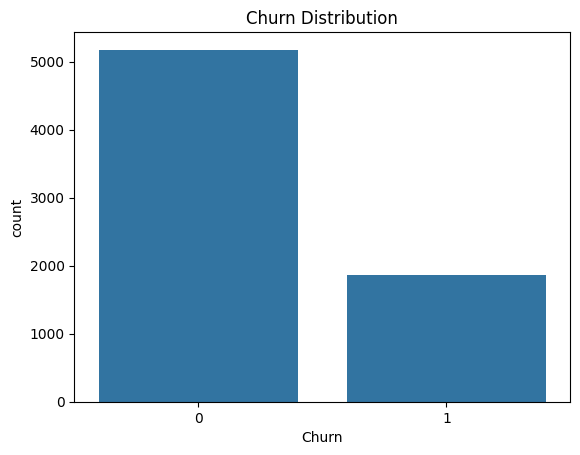

In [22]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

# 6-Data Preprocessing

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=42)
x_train["TotalCharges"] = pd.to_numeric(x_train["TotalCharges"], errors="coerce")
x_test["TotalCharges"] = pd.to_numeric(x_test["TotalCharges"], errors="coerce")

train_median = x_train["TotalCharges"].median()

x_train["TotalCharges"] = x_train["TotalCharges"].fillna(train_median)
x_test["TotalCharges"] = x_test["TotalCharges"].fillna(train_median)

cat_cols = [
"gender","Partner","Dependents","PhoneService",
"MultipleLines","InternetService","OnlineSecurity",
"OnlineBackup","DeviceProtection","TechSupport",
"StreamingTV","StreamingMovies","Contract",
"PaperlessBilling","PaymentMethod"
]
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# 7-Model Training and Prediction

In [24]:
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(x_train, y_train)
#____model 2_____________

xgb = XGBClassifier(
    n_estimators=280,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model2 = Pipeline([
    ("preprocess", preprocess),
    ("model", xgb)
])
model2.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [25]:
y_pred=rf_model.predict(x_test)
y_pred2 = model2.predict(x_test)

In [26]:
import joblib
joblib.dump(model2, "model.pkl")

['model.pkl']

# 8-Model Evaluation

In [27]:
print("Accuracy for RandomForest:", accuracy_score(y_test, y_pred))
#___________________
print("Accuracy for XGBoost:", accuracy_score(y_test, y_pred2))

Accuracy for RandomForest: 0.7693399574166075
Accuracy for XGBoost: 0.7665010645848119


In [28]:
print("RF")
print(classification_report(y_test, y_pred))

print("XGB")
print(classification_report(y_test, y_pred2))

RF
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1036
           1       0.54      0.83      0.66       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409

XGB
              precision    recall  f1-score   support

           0       0.91      0.75      0.83      1036
           1       0.54      0.80      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



In [29]:
print("ROC-AUC RF:", roc_auc_score(y_test, rf_model.predict_proba(x_test)[:,1]))
print("ROC-AUC XGB:", roc_auc_score(y_test, model2.predict_proba(x_test)[:,1]))

ROC-AUC RF: 0.8648144026830354
ROC-AUC XGB: 0.8585984970033228


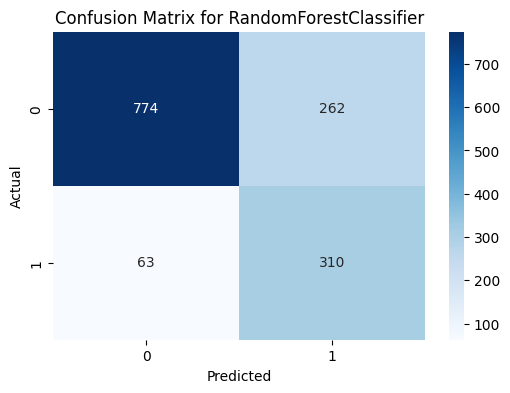

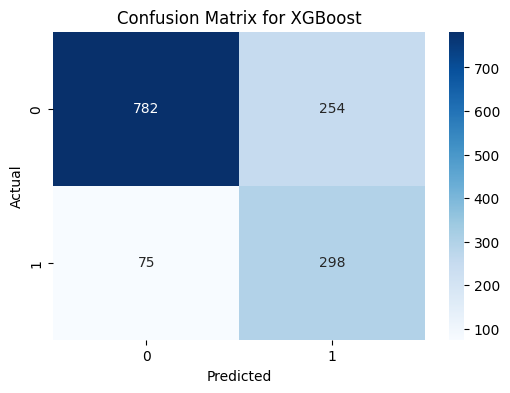

In [30]:


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for RandomForestClassifier")
plt.show()
cm = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for XGBoost")
plt.show()

# 9-Feature Importance

In [31]:
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

importance_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

print(importance_rf.head(10))
print("______________________")
print("XGBOOST Importance")
feature_names = model2.named_steps["preprocess"].get_feature_names_out()

importances = model2.named_steps["model"].feature_importances_

importance2 = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance2 = importance2.sort_values(
    by="Importance",
    ascending=False
)

print(importance2.head(10))

                                Feature  Importance
42                    remainder__tenure    0.127739
32         cat__Contract_Month-to-month    0.122719
44              remainder__TotalCharges    0.102188
34               cat__Contract_Two year    0.075156
43            remainder__MonthlyCharges    0.065896
14               cat__OnlineSecurity_No    0.061619
23                  cat__TechSupport_No    0.050247
12     cat__InternetService_Fiber optic    0.049886
39  cat__PaymentMethod_Electronic check    0.037302
33               cat__Contract_One year    0.022393
______________________
XGBOOST Importance
                                    Feature  Importance
32             cat__Contract_Month-to-month    0.316923
12         cat__InternetService_Fiber optic    0.074583
23                      cat__TechSupport_No    0.057377
15  cat__OnlineSecurity_No internet service    0.056834
14                   cat__OnlineSecurity_No    0.052729
11                 cat__InternetService_DSL    0.0

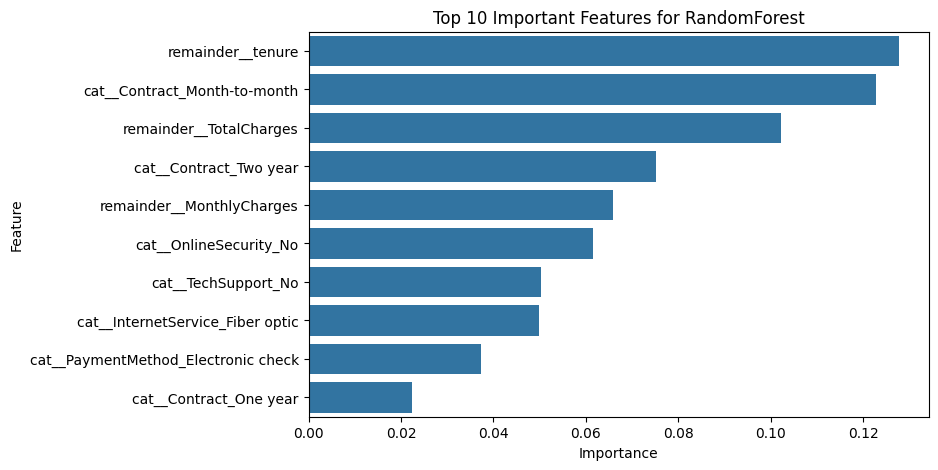

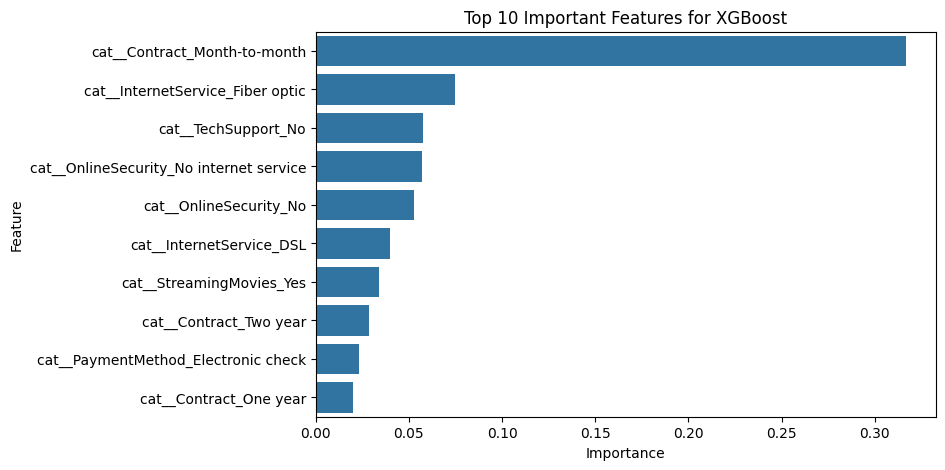

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_rf.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for RandomForest")
plt.show()
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance2.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for XGBoost")
plt.show()

# 10-SHAP for XGBoost

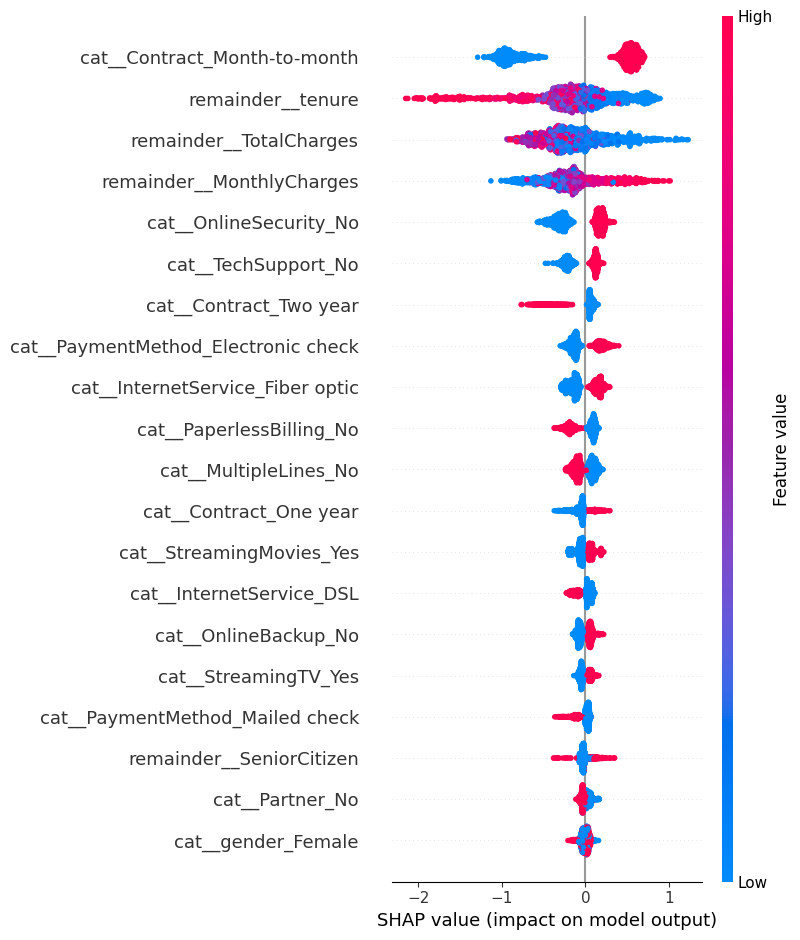

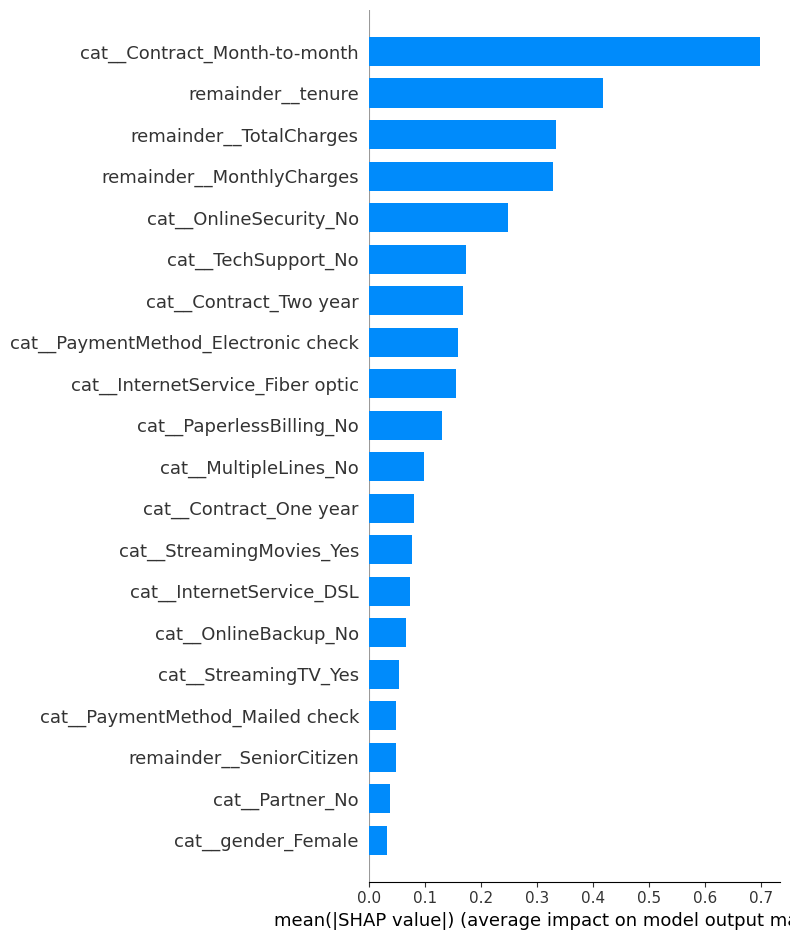

In [35]:
preprocessor = model2.named_steps["preprocess"]
xgb_model = model2.named_steps["model"]

x_test_encoded = preprocessor.transform(x_test)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(x_test_encoded)

shap.summary_plot(
    shap_values,
    x_test_encoded,
    feature_names=feature_names
)

shap.summary_plot(
    shap_values,
    x_test_encoded,
    feature_names=feature_names,
    plot_type="bar"
)

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[18],
    x_test_encoded[18],
    feature_names=feature_names
)

# 11-Business Insights

## Based on Random Forest, XGBoost & SHAP on XGBoost

- Both Random Forest and XGBoost models consistently identify Contract type as the strongest predictor of customer churn, with month-to-month contracts showing the highest churn risk.

- Customer tenure is a critical retention factor, where newer customers are significantly more likely to churn across both models.

- MonthlyCharges strongly influence churn, indicating that customers with higher monthly costs are more likely to leave due to price sensitivity.

- Services such as OnlineSecurity and TechSupport reduce churn probability, showing that customers who adopt value-added services are more likely to stay.

- InternetService type has a moderate and consistent effect on churn across both models.

- Random Forest shows higher sensitivity to financial features (MonthlyCharges, TotalCharges, Tenure), while XGBoost places more emphasis on behavioral and service-related features (Contract, OnlineSecurity, TechSupport).

- SHAP analysis (applied on XGBoost) provides both global and local interpretability:
  - Long-term contracts significantly reduce churn probability.
  - Low tenure increases churn risk.
  - High monthly charges push predictions toward churn.

- Overall, customer churn is mainly driven by contract flexibility, early customer experience, pricing structure, and service quality.

# 12-Business Recommendations

- Encourage customers to switch from month-to-month contracts to longer-term contracts through discounts, loyalty rewards, or bundled offers.

- Focus retention campaigns on new customers during their first months, as low-tenure customers are at the highest risk of churn.

- Monitor customers with high monthly charges and provide personalized offers or pricing plans to reduce price-related churn.

- Promote value-added services such as Online Security and Tech Support, since customers using these services show lower churn rates.

- Build an early warning system using the churn prediction model to identify high-risk customers and trigger proactive retention actions.

- Prioritize retention efforts on customers predicted as high-risk, allowing the company to allocate marketing and customer support resources more efficiently.

# 13- Conclusion

This project demonstrates the use of machine learning techniques to predict customer churn in a telecom dataset.

Two models were trained and evaluated: Random Forest and XGBoost. Both models achieved similar performance, but XGBoost showed stronger focus on key behavioral features such as Contract, OnlineSecurity, and TechSupport.

Random Forest provided a more balanced view of feature importance, including financial indicators like MonthlyCharges and TotalCharges.

Based on recall performance for the churn class, XGBoost was selected as the final model because correctly identifying customers likely to leave is more important than overall accuracy.

These insights can help businesses improve customer retention strategies by focusing on contract optimization, service quality, and support services.